In [2]:
import polars as pl
import matplotlib.pyplot as plt

df = pl.read_parquet("../parquets/F_binance_ethusdt_top_of_book.parquet")
df.null_count()


instrument,ingress_ts,seq_id,bid_price,bid_qty,ask_price,ask_qty
u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0


In [3]:
df.select(
    pl.len().alias("rows"),
    pl.col("instrument").n_unique().alias("instruments"),
    pl.col("seq_id").n_unique().alias("unique_seq_ids"),
)

rows,instruments,unique_seq_ids
u32,u32,u32
235270,1,235270


In [4]:
df.unique().height, df.height

(235270, 235270)

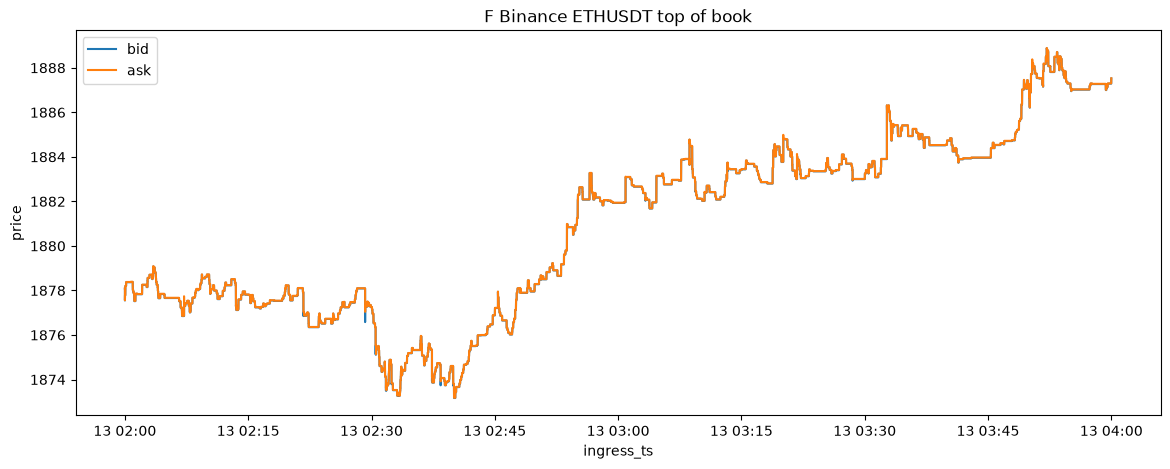

In [5]:
df_plot = df.sort("seq_id")

plt.figure(figsize=(14, 5))
plt.plot(df_plot["ingress_ts"], df_plot["bid_price"], label="bid")
plt.plot(df_plot["ingress_ts"], df_plot["ask_price"], label="ask")
plt.title("F Binance ETHUSDT top of book")
plt.xlabel("ingress_ts")
plt.ylabel("price")
plt.legend()
plt.show()

In [6]:
df.select(
    (pl.col("bid_price") <= 0).sum().alias("bad_bid_price"),
    (pl.col("ask_price") <= 0).sum().alias("bad_ask_price"),
    (pl.col("bid_qty") < 0).sum().alias("negative_bid_qty"),
    (pl.col("ask_qty") < 0).sum().alias("negative_ask_qty"),
)

bad_bid_price,bad_ask_price,negative_bid_qty,negative_ask_qty
u32,u32,u32,u32
0,0,0,0


In [7]:
df.select(
    (pl.col("bid_price") > pl.col("ask_price")).sum().alias("crossed_books"),
    (pl.col("bid_price") == pl.col("ask_price")).sum().alias("locked_books"),
)

crossed_books,locked_books
u32,u32
0,0


In [8]:
df = df.with_columns(
    spread=pl.col("ask_price") - pl.col("bid_price"),
    mid=(pl.col("ask_price") + pl.col("bid_price")) / 2,
).with_columns(
    spread_pct=pl.col("spread") / pl.col("mid") * 100
)

df.select(
    pl.col("spread_pct").quantile(0.99).alias("p99_spread_pct"),
    pl.col("spread_pct").max().alias("max_spread_pct"),
)

p99_spread_pct,max_spread_pct
f64,f64
0.002655,0.047409


In [9]:
df.sort("seq_id").select(pl.col("ingress_ts").is_sorted().alias("ingress_ts_monotonic_by_seq_id"))

ingress_ts_monotonic_by_seq_id
bool
false


In [10]:
df.sort("seq_id").select(pl.col("ingress_ts").diff().dt.total_microseconds().alias("step_us")).select((pl.col("step_us") < 0).sum().alias("reversals"), pl.col("step_us").filter(pl.col("step_us") < 0).min().abs().fill_null(0).alias("max_reversal_us"))

reversals,max_reversal_us
u32,i64
32,17
